# Blog Generator with Routing, Research + Refinement

`router` decides whether the topic needs live web research, then:

`router` -> (`researcher` | skip) -> `orchestrator` -> `worker` (fan-out) -> `reducer` -> `refiner`

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from typing import TypedDict, Annotated, List
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from pathlib import Path
import operator
import re

In [19]:
load_dotenv()

True

In [20]:
class ResearchDecision(BaseModel):
    needs_research: bool = Field(
        ..., description="True if the blog needs current facts, data or citations from the web"
    )
    reason: str = Field(..., description="One short sentence explaining the decision")


class SearchQueries(BaseModel):
    queries: List[str] = Field(..., description="3-4 focused web search queries")


class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")


class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [21]:
class State(TypedDict):
    topic: str
    needs_research: bool
    research_reason: str
    research: str
    sources: List[str]
    plan: Plan
    sections: Annotated[List[str], operator.add]
    draft: str
    final: str

In [22]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
search = TavilySearchResults(max_results=4)

In [23]:
def router(state: State) -> dict:

    decision = llm.with_structured_output(ResearchDecision).invoke(
        [
            SystemMessage(
                content=(
                    "Decide whether writing a blog on this topic needs live web research.\n\n"
                    "Ask: would a good blog on this topic state any figure, date, "
                    "version, price, or claim about the CURRENT state of the world?\n"
                    "  yes -> needs_research = true. Err on the side of true; stale "
                    "numbers are worse than a wasted search.\n"
                    "  no  -> needs_research = false. Reserve this for genuinely "
                    "timeless pieces: conceptual explainers, opinion, how-to, "
                    "creative writing, or advice with no factual claims to date."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    print(f"router: needs_research={decision.needs_research} ({decision.reason})")

    return {
        "needs_research": decision.needs_research,
        "research_reason": decision.reason,
    }


def route_research(state: State) -> str:
    return "researcher" if state["needs_research"] else "orchestrator"

In [24]:
def researcher(state: State) -> dict:

    queries = llm.with_structured_output(SearchQueries).invoke(
        [
            SystemMessage(
                content="Write 3-4 focused web search queries to research this blog topic."
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    # one Tavily call per query, de-duplicated by url
    seen, sources = set(), []
    for q in queries.queries:
        for hit in search.invoke({"query": q}):
            if hit["url"] in seen:
                continue
            seen.add(hit["url"])
            sources.append(hit)

    notes = "\n\n".join(
        f"[{i}] {s['title']}\n{s['url']}\n{s['content']}"
        for i, s in enumerate(sources, start=1)
    )

    return {"research": notes, "sources": [s["url"] for s in sources]}

In [25]:
def orchestrator(state: State) -> dict:

    research = state.get("research", "")

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a Blog Plan with 3-5 sections on the following topic. "
                    + (
                        "Ground the plan in the supplied research notes."
                        if research
                        else "Plan from general knowledge; no research was gathered."
                    )
                )
            ),
            HumanMessage(
                content=f"Topic: {state['topic']}"
                + (f"\n\nResearch notes:\n{research}" if research else "")
            ),
        ]
    )

    return {"plan": plan}

In [26]:
def distributer(state: State):
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"],
                "research": state.get("research", ""),
            },
        )
        for task in state["plan"].tasks
    ]

In [27]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    research = payload["research"]

    if research:
        instruction = (
            "Write one clean Markdown section. Use only facts supported by the "
            "research notes. Cite sources inline as [1], [2] matching the notes."
        )
    else:
        instruction = (
            "Write one clean Markdown section from general knowledge. "
            "Do not fabricate statistics or citations."
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=instruction),
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    + (f"Research notes:\n{research}\n\n" if research else "")
                    + "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [28]:
def reducer(state: State) -> dict:
    body = "\n\n".join(state["sections"]).strip()
    return {"draft": f"# {state['plan'].blog_title}\n\n{body}\n"}

In [29]:
def slugify(title: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")
    return slug or "blog"


def refiner(state: State) -> dict:

    polished = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Refine this blog draft. Remove repetition across sections, smooth the "
                    "transitions, keep any inline [n] citations intact, and do not invent "
                    "new facts. Return the full blog in Markdown."
                )
            ),
            HumanMessage(content=state["draft"]),
        ]
    ).content.strip()

    sources = state.get("sources", [])
    if sources:
        refs = "\n".join(f"{i}. {url}" for i, url in enumerate(sources, start=1))
        final_md = f"{polished}\n\n## Sources\n\n{refs}\n"
    else:
        final_md = f"{polished}\n"

    Path(slugify(state["plan"].blog_title) + ".md").write_text(
        final_md, encoding="utf-8"
    )

    return {"final": final_md}

In [30]:
graph = StateGraph(State)
graph.add_node("router", router)
graph.add_node("researcher", researcher)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)
graph.add_node("refiner", refiner)

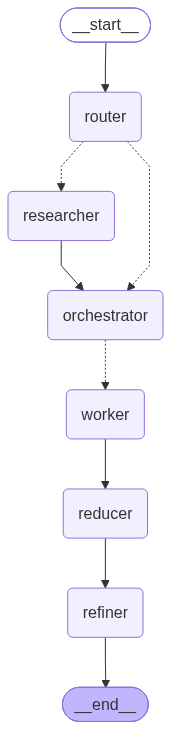

In [31]:
graph.add_edge(START, "router")
graph.add_conditional_edges("router", route_research, ["researcher", "orchestrator"])
graph.add_edge("researcher", "orchestrator")
graph.add_conditional_edges("orchestrator", distributer, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", "refiner")
graph.add_edge("refiner", END)

workflow = graph.compile()

workflow

In [ ]:
# time-sensitive topic: router should take the researcher branch
output = workflow.invoke({"topic": "Write a blog on Global Warming", "sections": []})

print("sources used:", len(output.get("sources", [])))
print(output["final"][:1200])

In [32]:
# timeless, conceptual topic: router should skip research
output = workflow.invoke(
    {"topic": "Write a blog on why recursion is hard for beginners", "sections": []}
)

print("sources used:", len(output.get("sources", [])))
print(output["final"][:600])

router: needs_research=False (Recursion as a computer science concept is a timeless topic focusing on cognitive load and mental models, requiring no live web data.)
sources used: 0
# Why Recursion is Hard for Beginners (And How to Finally Get It)

## The Dreaded Concept: What Makes Recursion So Intimidating?

At its core, recursion is a programming technique where a function calls itself to solve a smaller piece of a larger problem. It is elegant, mathematically sound, and used everywhere from traversing complex file systems to rendering computer graphics. 

So why does it strike fear into the hearts of nearly every coding beginner?

The hurdle isn't necessarily the syntax; it's the required shift in perspective. For months, beginners are taught to read code procedurally
